In [12]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re


DATA_PATH = 'train_submission.csv'

### Preprocessing


In [3]:

df_original = pd.read_csv(DATA_PATH, encoding='utf-8')

print("Before Cleaning: ",df_original.shape)

df_copy = df_original.copy()
df_copy.rename(columns={'Text': 'text', 'Label': 'target'}, inplace=True)

df_filtered = df_copy[~(df_copy.target.isna())|(df_copy.text.isna())|((df_copy.text == ""))]
print("After Cleaning", df_filtered.shape)

print("Number of unique languages: ",len(df_filtered.target.unique()))

Before Cleaning:  (190599, 3)
After Cleaning (190099, 3)
Number of unique languages:  389


In [4]:
test_df= pd.read_csv("test_without_labels.csv", encoding="utf-8")

In [5]:
len(test_df)

190567

In [6]:
n_train = df_filtered.shape[0]
n_test = test_df.shape[0]
n_languages = df_filtered['target'].nunique()

print(f"Training samples: {n_train}, Unlabeled test samples: {n_test}")
print(f"Number of languages: {n_languages}")
print(f"Example languages: {df_filtered['target'].unique()[:5]}")  # First 5 languages


Training samples: 190099, Unlabeled test samples: 190567
Number of languages: 389
Example languages: ['hau' 'nob' 'wln' 'quh' 'scn']


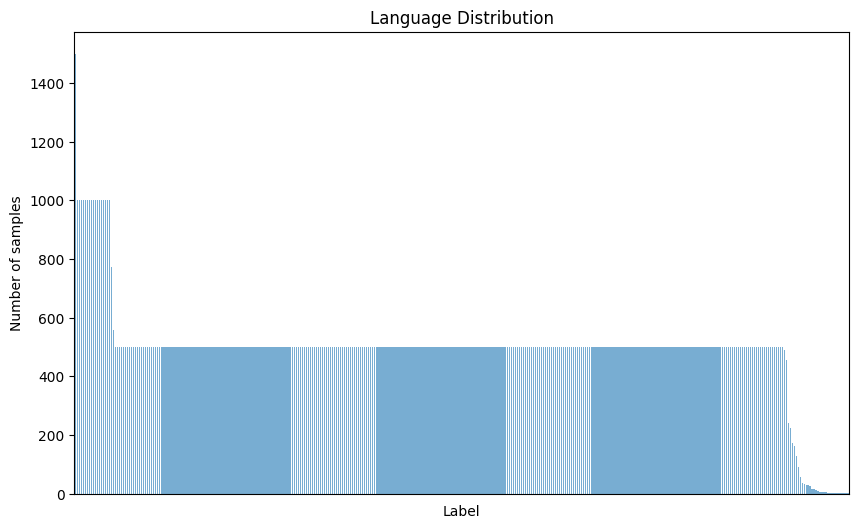

In [8]:

# Your existing plot code (example)
plt.figure(figsize=(10, 6))
df_original['Label'].value_counts().plot(kind='bar', width=0.8, alpha=0.6)

# Remove x-axis labels (language names)
plt.xticks([])  # This removes all the x-axis labels

# Keep axis labels and title
plt.xlabel('Label')
plt.ylabel('Number of samples')
plt.title('Language Distribution')

plt.show()


count    190599.000000
mean         23.792717
std          57.635160
min           1.000000
25%          10.000000
50%          16.000000
75%          27.000000
max       11557.000000
Name: text_length, dtype: float64


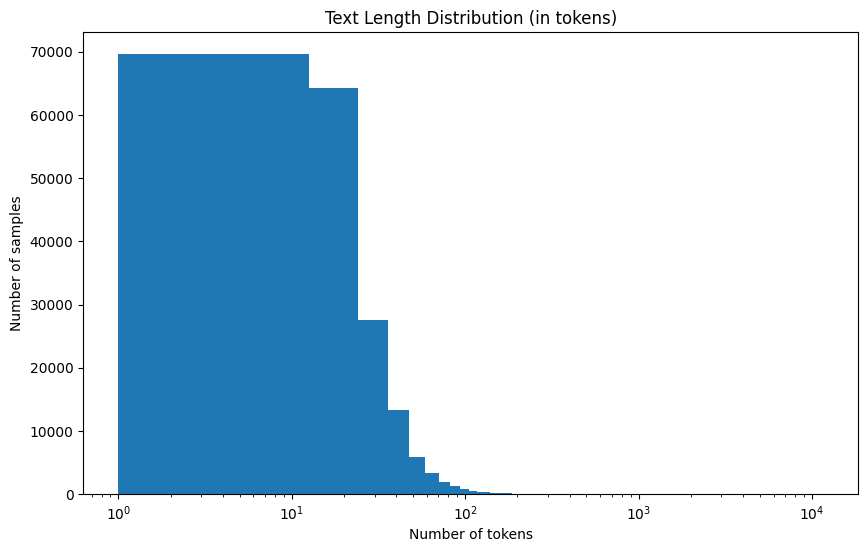

In [10]:
df_original['text_length'] = df_original['Text'].apply(lambda x: len(x.split()))

print(df_original['text_length'].describe())

plt.figure(figsize=(10,6))
plt.xscale('log')
plt.hist(df_original['text_length'], bins=1000)
plt.title('Text Length Distribution (in tokens)')
plt.xlabel('Number of tokens')
plt.ylabel('Number of samples')
plt.show()


In [ ]:
average_length = np.mean(df_original['text_length'])
print(f"Average text length: {average_length:.2f} tokens")

Average text length: 23.79 tokens


In [14]:

def contains_emoji(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F700-\U0001F77F"  # alchemical symbols
        "\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
        "\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
        "\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
        "\U0001FA00-\U0001FA6F"  # Chess Symbols
        "\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
        "\U00002702-\U000027B0"  # Dingbats
        "]+"
    )
    return bool(emoji_pattern.search(text))

df_filtered['has_emoji'] = df_filtered['text'].apply(contains_emoji)
print(df_filtered['has_emoji'].value_counts())


has_emoji
False    189432
True        667
Name: count, dtype: int64


C:\Users\Arij\AppData\Local\Temp\ipykernel_3928\3702532853.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['has_emoji'] = df_filtered['text'].apply(contains_emoji)


In [13]:

# Minimal preprocessing
def clean_text(text):
    return str(text).lower().replace('\n', ' ').replace('\r', '').strip()
train_df=df_filtered
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
test_df['cleaned_text'] = test_df['Text'].apply(clean_text)

# Cell 3: GPU-optimized model setup
# Create label mappings
labels = train_df['target'].unique()
label2id = {label: idx for idx, label in enumerate(labels)}
id2label = {idx: label for label, idx in label2id.items()}


C:\Users\Arij\AppData\Local\Temp\ipykernel_3928\3370599181.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['cleaned_text'] = train_df['text'].apply(clean_text)
